In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import sys
from pathlib import Path
import importlib
import numpy as np
import torch
import matplotlib.pyplot as plt

# Asegura que el ROOT esté en sys.path para poder importar src/*
ROOT = Path().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("ROOT:", ROOT)
print("Python:", sys.version)
print("Torch:", torch.__version__)


ROOT: C:\Users\mateo garcia\Documents\A master\Tesis\QPINNs-2025
Python: 3.11.13 | packaged by conda-forge | (main, Jun  4 2025, 14:39:58) [MSC v.1943 64 bit (AMD64)]
Torch: 2.5.1+cpu


In [3]:
import importlib

# (opcional) recarga módulos si estás editando código en caliente
import src.trainer.schrodinger_train as sch_train
import src.nn.DVPDESolver as dv_solver_mod
import src.problems.schrodinger as sch_prob

importlib.reload(sch_train)
importlib.reload(dv_solver_mod)
importlib.reload(sch_prob)

# ===== Imports correctos =====
from src.trainer.schrodinger_train import train
from src.nn.DVPDESolver import DVPDESolver

from src.problems.schrodinger import build_eq_params, sanity_check
from src.problems.schrodinger.problem import build_problem

from src.utils.logger import Logging

print("Imports OK.")



Imports OK.


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype  = torch.float32   # para pruebas rápidas
print("device:", device, "| dtype:", dtype)

# ====== PARAMETROS DEL PROBLEMA: BARRERA ======
eq_params = build_eq_params(
    "barrier",
    L=1.0,
    T=0.2,
    n_level=1,      # ojo: en barrier es índice 0-based en tu exact numérica
    mass=1.0,
    hbar=1.0,
    # barrera
    V0=10.0,
    barrier_width=0.2,
    x_center=0.6,
    # malla para exact numérico
    num_grid=400,
)

print("eq_params:", eq_params)


device: cpu | dtype: torch.float32
eq_params: {'example': 'barrier', 'L': 1.0, 'T': 0.2, 'mass': 1.0, 'hbar': 1.0, 'n_level': 1, 'x_min': 0.0, 'x_max': 1.0, 'omega': 1.0, 'V0': 10.0, 'barrier_width': 0.2, 'x_center': 0.6, 'num_grid': 400}


In [5]:
from pathlib import Path
dv_file = ROOT / "src" / "nn" / "DVPDESolver.py"
txt = dv_file.read_text(encoding="utf-8", errors="ignore")

# buscamos el patrón correcto de rotación: re2 = re*c + im*s ; im2 = im*c - re*s
ok1 = ("re2 = re * c + im * s" in txt) or ("re2 = re*c + im*s" in txt)
ok2 = ("im2 = im * c - re * s" in txt) or ("im2 = im*c - re*s" in txt)

print("DVPDESolver.py:", dv_file)
print("Global-phase sign OK?:", ok1 and ok2)

if not (ok1 and ok2):
    print("\n⚠️  Parece que el signo NO está corregido.")
    print("    Corrige _apply_global_phase para implementar exp(-i ω t).")


DVPDESolver.py: C:\Users\mateo garcia\Documents\A master\Tesis\QPINNs-2025\src\nn\DVPDESolver.py
Global-phase sign OK?: True


In [6]:
def predict_psi(model, t, x):
    """Devuelve psi_pred (complejo) como tensor complejo shape [N,1]."""
    tx = torch.cat([t, x], dim=1)
    out = model(tx)
    re = out[:, 0:1]
    im = out[:, 1:2]
    return re + 1j * im

def exact_psi(problem, n_level, t, x):
    """Devuelve psi_exact (complejo) y también E."""
    re_e, im_e, E = problem["exact"](n_level, t, x)
    return (re_e + 1j * im_e), E

def density(psi):
    return (psi.real**2 + psi.imag**2)

def l2_rel(a, b, eps=1e-12):
    """L2 relativo estándar."""
    num = torch.sqrt(torch.mean(torch.abs(a - b)**2))
    den = torch.sqrt(torch.mean(torch.abs(b)**2)) + eps
    return num / den

def l2_rel_phase_invariant(psi_pred, psi_exact, eps=1e-12):
    """L2 relativo tras alinear fase global óptima alpha."""
    alpha = (torch.mean(torch.conj(psi_pred) * psi_exact) /
             (torch.mean(torch.conj(psi_pred) * psi_pred) + eps))
    psi_corr = alpha * psi_pred
    return l2_rel(psi_corr, psi_exact)

def plot_density_1d(problem, model, title="", n_pts=600):
    device_ = next(model.parameters()).device
    dtype_  = next(model.parameters()).dtype

    x = torch.linspace(problem["x_min"], problem["x_max"], n_pts, device=device_, dtype=dtype_).reshape(-1,1)

    for t_val, tag in [(0.0, "t=0"), (float(problem["T"]), f"t=T={problem['T']}")]:
        t = torch.full_like(x, t_val)
        with torch.no_grad():
            psi_p = predict_psi(model, t, x)
            psi_e, _ = exact_psi(problem, problem["n_level"], t, x)
            rho_p = density(psi_p).detach().cpu().numpy().flatten()
            rho_e = density(psi_e).detach().cpu().numpy().flatten()
            x_np  = x.detach().cpu().numpy().flatten()

        plt.figure(figsize=(7.2,3.4))
        plt.plot(x_np, rho_e, label="Exact")
        plt.plot(x_np, rho_p, "--", label="Pred")
        plt.title(f"{title} |psi(x,{tag})|^2")
        plt.xlabel("x")
        plt.ylabel("|psi|^2")
        plt.legend()
        plt.tight_layout()
        plt.show()

def quick_metrics(problem, model, t_val=None, n_pts=400):
    """Imprime L2 complejo, L2 fase-invariante y L2 densidad."""
    device_ = next(model.parameters()).device
    dtype_  = next(model.parameters()).dtype

    x = torch.linspace(problem["x_min"], problem["x_max"], n_pts, device=device_, dtype=dtype_).reshape(-1,1)
    if t_val is None:
        t_val = float(problem["T"])
    t = torch.full_like(x, float(t_val))

    with torch.no_grad():
        psi_p = predict_psi(model, t, x)
        psi_e, E = exact_psi(problem, problem["n_level"], t, x)
        rho_p = density(psi_p)
        rho_e = density(psi_e)

        l2_c   = l2_rel(psi_p, psi_e).item()
        l2_ph  = l2_rel_phase_invariant(psi_p, psi_e).item()
        l2_rho = l2_rel(rho_p, rho_e).item()

    print(f"[Metrics @ t={t_val}] L2_complex={l2_c:.4f} | L2_phase={l2_ph:.4f} | L2_density={l2_rho:.4f}")
    return E


In [7]:
problem = build_problem(eq_params, device=device, dtype=dtype)

args_stage1 = {
    "eq_params": eq_params,
    "device": device,
    "dtype": dtype,
    "problem": "schrodinger",

    # training (rápido)
    "epochs": 300,
    "warmup_epochs": 0,
    "lr": 1e-3,
    "batch_size": 64,
    "print_every": 10,

    # losses: SOLO IC (PDE apagado)
    "w_pde": 0.0,
    "w_pde_i": 1.0,     # irrelevante si w_pde=0
    "w_ic": 800.0,
    "w_ic_i": 5.0,
    "w_norm": 0.0,

    # BC dura
    "hard_bc": True,
    "w_bc": 0.0,
    "hard_bc_power": 1.0,
    "hard_bc_scale": 4.0,

    # IC sampling / val
    "ic_grid": True,
    "N_norm": 400,
    "N_val": 400,

    # DV circuit
    "num_qubits": 4,
    "num_quantum_layers": 2,
    "shots": None,
    "noise": False,
    "encoding": "angle",
    "q_ansatz": "sim_circ_19",

    # hybrid net
    "classic_network": [2, 64, 64, 2],

    # performance / métricas
    "pde_chunk_size": 64,
    "l2_every": 10,

    # fase global (se mantiene igual en ambas etapas)
    "global_phase": True,
    "global_phase_spatial_only": True,
    "global_phase_omega_init": 5.0,
    "use_lbfgs": False,

    # estabilidad de ángulos (si tu DVPDESolver lo soporta)
    "angle_squash": True,
}

model = DVPDESolver(args_stage1, logger=Logging(ROOT / "results"), device=device).to(device)
print("Model dtype:", next(model.parameters()).dtype)


Model dtype: torch.float32


QNode encontrado en quantum_layer.circuit
0: ─╭AngleEmbedding(M0)──RX(-0.01)──RZ(-0.04)─╭||─╭X───────────────╭●──────────RX(0.63)─ ···
1: ─├AngleEmbedding(M0)──RX(0.79)───RZ(0.25)──├||─│─────╭●─────────╰X──────────RX(-0.65) ···
2: ─├AngleEmbedding(M0)──RX(0.26)───RZ(-0.06)─├||─│──╭●─╰X──────────RX(-0.30)──RZ(-0.24) ···
3: ─╰AngleEmbedding(M0)──RX(-0.80)──RZ(0.21)──╰||─╰●─╰X──RX(-0.04)──RZ(-0.65)─────────── ···

0: ··· ──RZ(0.14)─╭||─╭X───────╭●─┤  <Z>
1: ··· ──RZ(0.32)─├||─│─────╭●─╰X─┤  <Z>
2: ··· ───────────├||─│──╭●─╰X────┤  <Z>
3: ··· ───────────╰||─╰●─╰X───────┤  <Z>

M0 = 
tensor([0., 0., 0., 0.])


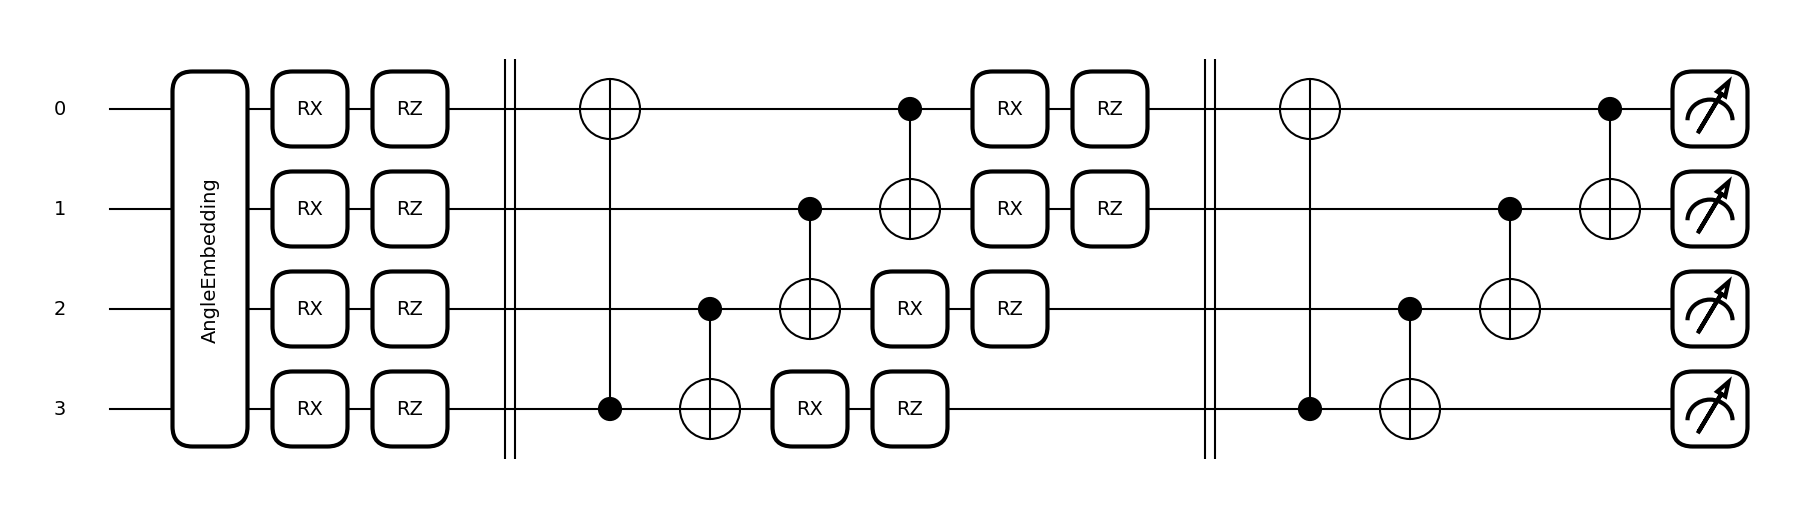

In [9]:
import torch
import pennylane as qml
import matplotlib.pyplot as plt

ql = model.quantum_layer

# Encontrar el QNode (ya viste que está en quantum_layer.circuit)
qnode = getattr(ql, "qnode", None)
if qnode is None:
    for name, val in vars(ql).items():
        if isinstance(val, qml.QNode):
            print(f"QNode encontrado en quantum_layer.{name}")
            qnode = val
            break
if qnode is None:
    raise RuntimeError("No encontré un QNode dentro de model.quantum_layer")

# Input para dibujar (ajusta longitud según tu circuito)
dev = next(model.parameters()).device
dt  = next(model.parameters()).dtype

# Prueba con 4 (tu num_qubits=4); si falla, baja a 2.
n = model.args.get("num_qubits", 4) if hasattr(model, "args") else 4
x_draw = torch.zeros(n, device=dev, dtype=dt)
if n >= 2:
    x_draw[0] = 0.0  # t
    x_draw[1] = 0.0  # x

# 1) ASCII
try:
    drawer_txt = qml.draw(qnode)     # <- sin expansion_strategy
    print(drawer_txt(x_draw))
except Exception as e:
    print("No pude dibujar en ASCII con ese x_draw:", repr(e))
    print("Probando con vector de 2 entradas...")
    x2 = torch.tensor([0.0, 0.0], device=dev, dtype=dt)
    drawer_txt = qml.draw(qnode)
    print(drawer_txt(x2))

# 2) Figura (matplotlib)
try:
    drawer_fig = qml.draw_mpl(qnode) # <- sin expansion_strategy
    fig, ax = drawer_fig(x_draw)
    plt.show()
except Exception as e:
    print("No pude dibujar con draw_mpl con ese x_draw:", repr(e))
    print("Probando con vector de 2 entradas...")
    x2 = torch.tensor([0.0, 0.0], device=dev, dtype=dt)
    drawer_fig = qml.draw_mpl(qnode)
    fig, ax = drawer_fig(x2)
    plt.show()


In [8]:
# Manteniendo tus tamaños rápidos:
train(model, N_f=512, N_b=0, N_0=1024)

print("\nEtapa 1 (IC-only) terminada.")
plot_density_1d(problem, model, title="Etapa 1")
E = quick_metrics(problem, model, t_val=0.0)


INFO:src.utils.logger:The circuit used in the study:
INFO:src.utils.logger:It: 1, Loss: 1.359e+03, Loss_res: 1.299e+01,  Loss_bcs: 0.000e+00, Loss_ut_ics: 1.699e+00, Loss_norm: 6.399e-01, Loss_gauge: 0.000e+00, w_pde: 0.00e+00, L^2_error: 1.092e+00, lr: 1.000e-03, Time: 4.51e+00
INFO:src.utils.logger:Model state saved to C:\Users\mateo garcia\Documents\A master\Tesis\QPINNs-2025\results\2026-02-04_09-59-35-720663\model.pth
INFO:src.utils.logger:Model weights saved to C:\Users\mateo garcia\Documents\A master\Tesis\QPINNs-2025\results\2026-02-04_09-59-35-720663\model_weights.pth
INFO:src.utils.logger:It: 10, Loss: 8.255e+02, Loss_res: 7.036e-01,  Loss_bcs: 0.000e+00, Loss_ut_ics: 1.032e+00, Loss_norm: 9.759e-01, Loss_gauge: 0.000e+00, w_pde: 0.00e+00, L^2_error: 9.940e-01, lr: 1.000e-03, Time: 3.32e+01
INFO:src.utils.logger:Model state saved to C:\Users\mateo garcia\Documents\A master\Tesis\QPINNs-2025\results\2026-02-04_09-59-35-720663\model.pth
INFO:src.utils.logger:Model weights saved

KeyboardInterrupt: 

In [9]:
# Calcula E/hbar usando exact (en cualquier x0 sirve)
device_ = next(model.parameters()).device
dtype_  = next(model.parameters()).dtype

x0 = torch.tensor([[0.37]], device=device_, dtype=dtype_)
t0 = torch.zeros_like(x0)

with torch.no_grad():
    psi_e0, E = exact_psi(problem, problem["n_level"], t0, x0)
omega_star = float((E / problem["hbar"]).detach().cpu())

print("E =", float(E.detach().cpu()))
print("omega_star = E/hbar =", omega_star)

# set + freeze
if hasattr(model, "global_phase_omega"):
    model.global_phase_omega.data.fill_(omega_star)
    model.global_phase_omega.requires_grad_(False)
    print("✅ omega fijada y congelada.")
else:
    print("⚠️ Tu modelo no tiene global_phase_omega. Revisa DVPDESolver.")


E = 21.45040512084961
omega_star = E/hbar = 21.45040512084961
✅ omega fijada y congelada.


INFO:src.utils.logger:It: 1, Loss: 1.116e+00, Loss_res: 2.407e+01,  Loss_bcs: 0.000e+00, Loss_ut_ics: 1.094e-03, Loss_norm: 5.266e-05, Loss_gauge: 0.000e+00, w_pde: 1.00e-02, L^2_error: 4.096e-02, lr: 1.000e-03, Time: 1.47e+00
INFO:src.utils.logger:Model state saved to C:\Users\mateo garcia\Documents\A master\Tesis\QPINNs-2025\results\2025-12-23_15-22-55-421334\model.pth
INFO:src.utils.logger:Model weights saved to C:\Users\mateo garcia\Documents\A master\Tesis\QPINNs-2025\results\2025-12-23_15-22-55-421334\model_weights.pth
INFO:src.utils.logger:It: 10, Loss: 4.008e+00, Loss_res: 2.589e+01,  Loss_bcs: 0.000e+00, Loss_ut_ics: 1.767e-03, Loss_norm: 6.044e-04, Loss_gauge: 0.000e+00, w_pde: 1.00e-01, L^2_error: 3.070e-02, lr: 1.000e-03, Time: 1.38e+01
INFO:src.utils.logger:Model state saved to C:\Users\mateo garcia\Documents\A master\Tesis\QPINNs-2025\results\2025-12-23_15-22-55-421334\model.pth
INFO:src.utils.logger:Model weights saved to C:\Users\mateo garcia\Documents\A master\Tesis\QP


Etapa 2 (Physics-informed) terminada.


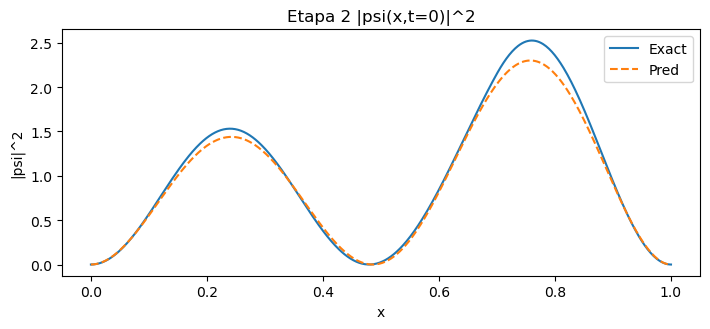

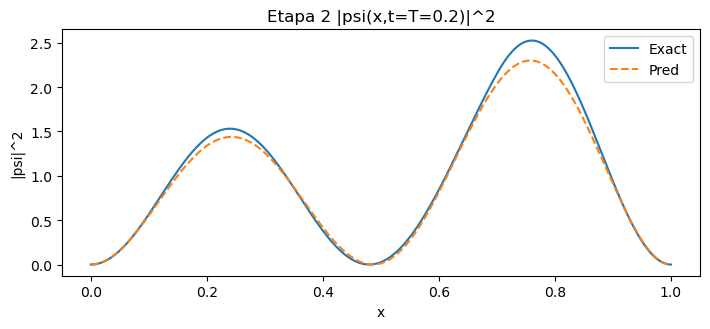

[Metrics @ t=0.2] L2_complex=0.0351 | L2_phase=0.0243 | L2_density=0.0677


In [10]:
# Actualiza args dentro del modelo (train() lee model.args)
model.args["epochs"] = 450
model.args["warmup_epochs"] = 100

model.args["w_pde"] = 1.0
model.args["w_pde_i"] = 1.0       # importante: NO 10
model.args["w_norm"] = 10.0

# dejamos IC igual
model.args["w_ic"] = 800.0
model.args["w_ic_i"] = 5.0

model.args["use_lbfgs"] = False
model.args["angle_squash"] = True

train(model, N_f=512, N_b=0, N_0=1024)

print("\nEtapa 2 (Physics-informed) terminada.")
plot_density_1d(problem, model, title="Etapa 2")
E = quick_metrics(problem, model, t_val=float(problem["T"]))


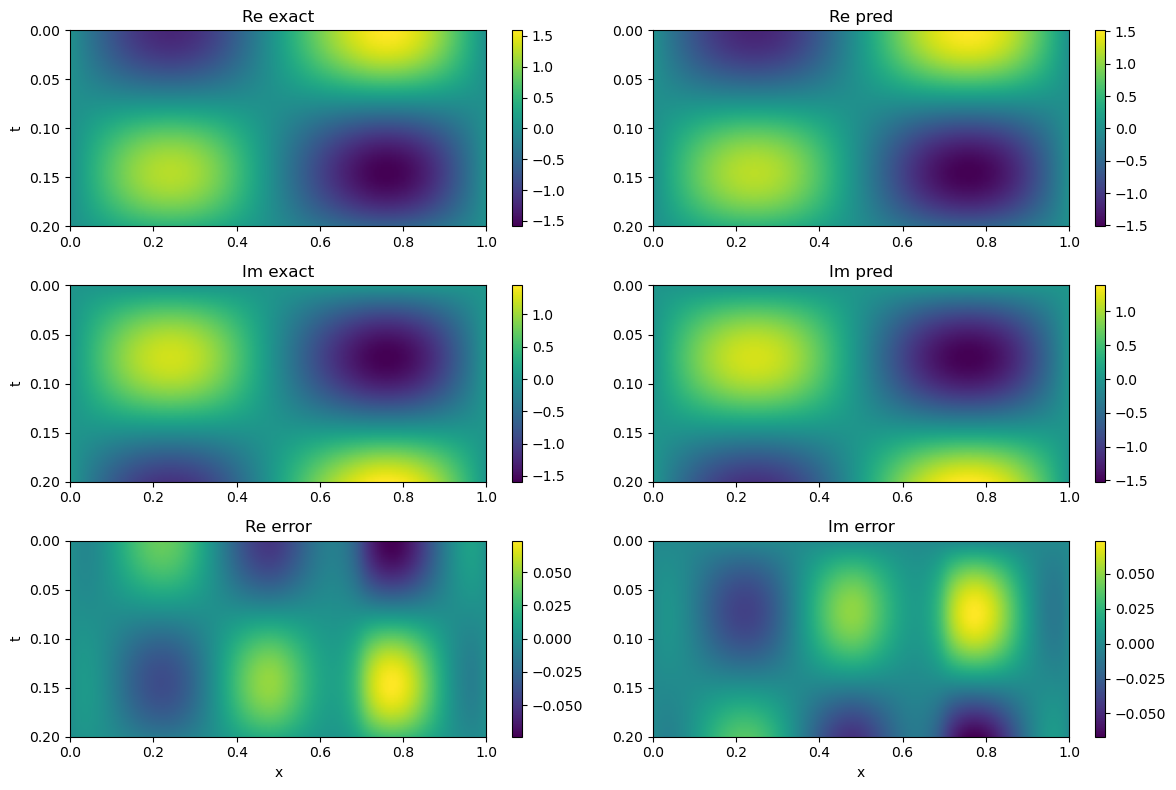

In [11]:
import numpy as np

Nt, Nx = 80, 220
t_grid = torch.linspace(0.0, float(problem["T"]), Nt, device=device_, dtype=dtype_).reshape(-1,1)
x_grid = torch.linspace(problem["x_min"], problem["x_max"], Nx, device=device_, dtype=dtype_).reshape(-1,1)

# mallado tipo (Nt*Nx, 1)
TT = t_grid.repeat(1, Nx).reshape(-1,1)
XX = x_grid.repeat(Nt, 1)

with torch.no_grad():
    re_ex, im_ex, _ = problem["exact"](problem["n_level"], TT, XX)
    y_pr = model(torch.cat([TT, XX], dim=1))
    re_pr, im_pr = y_pr[:,0:1], y_pr[:,1:2]

re_ex = re_ex.reshape(Nt, Nx).detach().cpu().numpy()
im_ex = im_ex.reshape(Nt, Nx).detach().cpu().numpy()
re_pr = re_pr.reshape(Nt, Nx).detach().cpu().numpy()
im_pr = im_pr.reshape(Nt, Nx).detach().cpu().numpy()

re_er = re_pr - re_ex
im_er = im_pr - im_ex

extent = [float(problem["x_min"]), float(problem["x_max"]), float(problem["T"]), 0.0]

plt.figure(figsize=(12,8))

plt.subplot(3,2,1); plt.imshow(re_ex, aspect="auto", extent=extent); plt.title("Re exact"); plt.ylabel("t"); plt.colorbar()
plt.subplot(3,2,2); plt.imshow(re_pr, aspect="auto", extent=extent); plt.title("Re pred");  plt.colorbar()

plt.subplot(3,2,3); plt.imshow(im_ex, aspect="auto", extent=extent); plt.title("Im exact"); plt.ylabel("t"); plt.colorbar()
plt.subplot(3,2,4); plt.imshow(im_pr, aspect="auto", extent=extent); plt.title("Im pred");  plt.colorbar()

plt.subplot(3,2,5); plt.imshow(re_er, aspect="auto", extent=extent); plt.title("Re error"); plt.xlabel("x"); plt.ylabel("t"); plt.colorbar()
plt.subplot(3,2,6); plt.imshow(im_er, aspect="auto", extent=extent); plt.title("Im error"); plt.xlabel("x"); plt.colorbar()

plt.tight_layout()
plt.show()


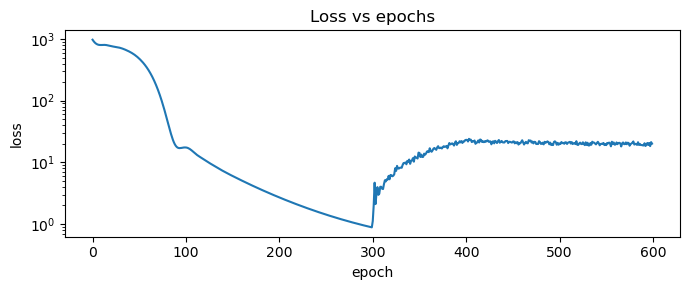

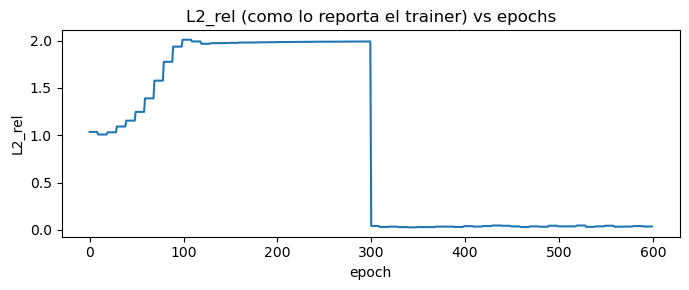

In [12]:
loss_hist = np.array(getattr(model, "loss_history", []), dtype=float)
l2_hist   = np.array(getattr(model, "l2_rel_history", []), dtype=float)

plt.figure(figsize=(7,3))
if len(loss_hist) > 0:
    plt.plot(loss_hist)
plt.yscale("log")
plt.title("Loss vs epochs")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,3))
if len(l2_hist) > 0:
    plt.plot(l2_hist)
plt.title("L2_rel (como lo reporta el trainer) vs epochs")
plt.xlabel("epoch")
plt.ylabel("L2_rel")
plt.tight_layout()
plt.show()


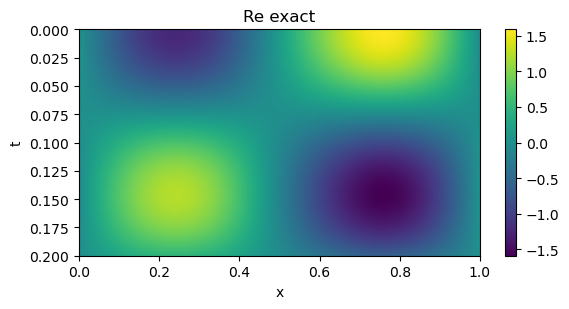

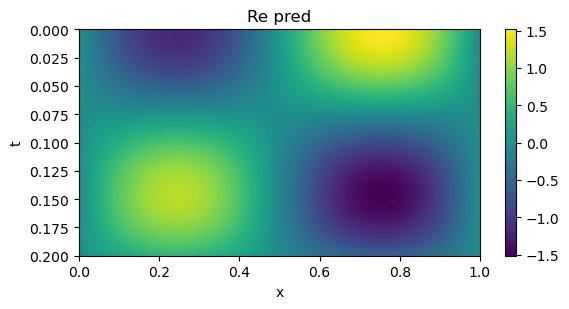

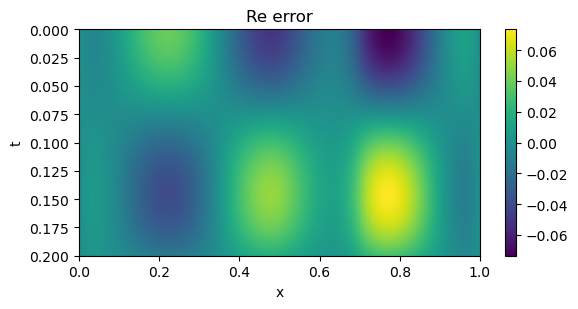

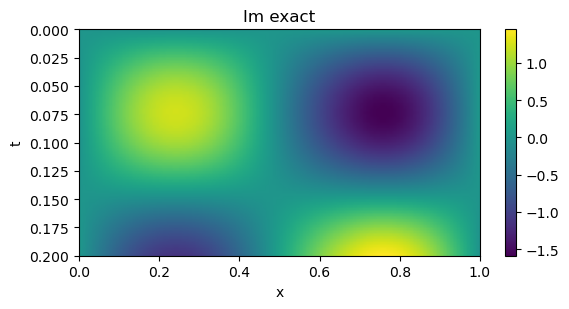

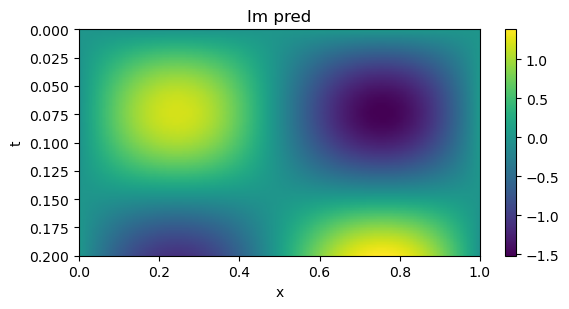

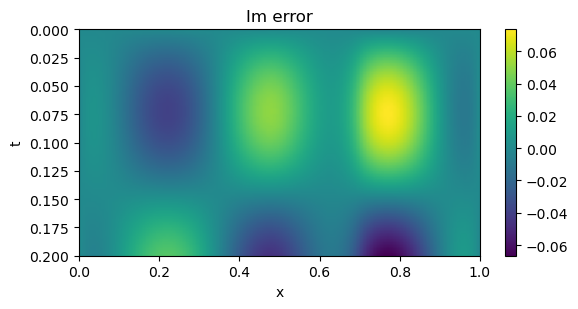

In [13]:
def plot_heatmaps(problem, model, nx=120, nt=80):
    device_ = next(model.parameters()).device
    dtype_  = next(model.parameters()).dtype

    x = torch.linspace(problem["x_min"], problem["x_max"], nx, device=device_, dtype=dtype_).reshape(-1,1)
    t = torch.linspace(0.0, float(problem["T"]), nt, device=device_, dtype=dtype_).reshape(-1,1)

    TT, XX = torch.meshgrid(t.squeeze(1), x.squeeze(1), indexing="ij")
    tx = torch.stack([TT.reshape(-1), XX.reshape(-1)], dim=1)

    with torch.no_grad():
        out = model(tx)
        re_p = out[:,0].reshape(nt, nx).detach().cpu().numpy()
        im_p = out[:,1].reshape(nt, nx).detach().cpu().numpy()

        re_e, im_e, _ = problem["exact"](problem["n_level"], tx[:,0:1], tx[:,1:2])
        re_e = re_e.reshape(nt, nx).detach().cpu().numpy()
        im_e = im_e.reshape(nt, nx).detach().cpu().numpy()

    def show(A, title):
        plt.figure(figsize=(6,3.2))
        plt.imshow(A, aspect="auto", origin="upper",
                   extent=[float(problem["x_min"]), float(problem["x_max"]), float(problem["T"]), 0.0])
        plt.colorbar()
        plt.title(title)
        plt.xlabel("x")
        plt.ylabel("t")
        plt.tight_layout()
        plt.show()

    show(re_e, "Re exact")
    show(re_p, "Re pred")
    show(re_p - re_e, "Re error")

    show(im_e, "Im exact")
    show(im_p, "Im pred")
    show(im_p - im_e, "Im error")

plot_heatmaps(problem, model)
